### QM9 noise scheduler comparasion

#### predefined vs scaled vs learned_adaptive

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from equivariant_diffusion.en_diffusion import PredefinedNoiseSchedule, ScaledNoiseSchedule, LearnedAdaptiveNoiseSchedule
from configs.datasets_config import qm9_with_h

In [13]:
NUM_STEPS = 1000
PRECISION = 1e-4          
POLY_POWER = 2.0          
SCALED_POLY_POWER = 2.0
DEVICE = "cpu"
DATASET_INFO = qm9_with_h

In [14]:
def extract_gamma_state_dict(ckpt_path: str):
    """Return only the gamma.* weights (prefix stripped) from a checkpoint saved as an OrderedDict."""
    sd = torch.load(ckpt_path, map_location="cpu")
    gamma_sd = {k[len("gamma."):]: v for k, v in sd.items() if k.startswith("gamma.")}
    if not gamma_sd:
        raise RuntimeError(f"No 'gamma.*' keys found in checkpoint: {ckpt_path}")
    return gamma_sd

def build_schedule_learned(input_dim: int, gamma_sd: dict, LearnedAdaptiveNoiseScheduleCls):
    """Instantiate the learned schedule and load weights."""
    model = LearnedAdaptiveNoiseScheduleCls(dataset_info=None, noise_context=None, input_dim=input_dim)
    model.load_state_dict(gamma_sd, strict=True)
    model.eval()
    return model

def gamma_to_curves(gamma: torch.Tensor):
    """
    Convert γ(t) to α(t), σ(t), SNR(t), logSNR(t) using the common log-SNR parameterization:
      σ² = sigmoid(γ), α² = sigmoid(−γ) = 1 − sigmoid(γ), SNR = exp(−γ), logSNR = −γ
    """
    sigma2 = torch.sigmoid(gamma)
    alpha2 = torch.sigmoid(-gamma)
    alpha = torch.sqrt(alpha2)
    sigma = torch.sqrt(sigma2)
    snr = torch.exp(-gamma)
    log_snr = -gamma
    return alpha, sigma, snr, log_snr

In [15]:
def predefined_vs_scaled():
    # x-axis (1..T)
    timesteps = torch.arange(1, NUM_STEPS + 1, dtype=torch.float32, device=DEVICE)
    t_norm = (timesteps / NUM_STEPS).unsqueeze(1)  # [T,1]

    all_series = []  # list of dicts: {label, alpha, sigma, snr, log_snr, gamma}

    # --- PREDEFINED POLYNOMIAL (non-scaled) ---
    poly_label = f"Polynomial (p={POLY_POWER:g})"
    poly_sched = PredefinedNoiseSchedule(noise_schedule=f"polynomial_{POLY_POWER}", timesteps=NUM_STEPS, precision=PRECISION).to(DEVICE)
    with torch.no_grad():
        gamma_poly = poly_sched(t_norm).squeeze(-1)
    alpha, sigma, snr, log_snr = gamma_to_curves(gamma_poly)
    all_series.append({
        "label": poly_label, "alpha": alpha.cpu(), "sigma": sigma.cpu(),
        "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma_poly.cpu()
    })

    # --- SCALED POLYNOMIAL ---
    N_NODES_FOR_PLOT = min(qm9_with_h['n_nodes'].keys())
    scaled_label = f"Scaled Polynomial (p={SCALED_POLY_POWER:g}, n={N_NODES_FOR_PLOT})"
    scaled_poly_sched = ScaledNoiseSchedule(
        dataset_info=DATASET_INFO,
        noise_schedule=f"scaled_polynomial_{SCALED_POLY_POWER}",
        timesteps=NUM_STEPS,
        precision=PRECISION
    ).to(DEVICE)
    with torch.no_grad():
        n_nodes_vec = torch.full((NUM_STEPS, 1), float(N_NODES_FOR_PLOT), device=DEVICE)
        gamma_scaled = scaled_poly_sched(t_norm, n_nodes_vec).squeeze(-1)
    alpha, sigma, snr, log_snr = gamma_to_curves(gamma_scaled)
    all_series.append({
        "label": scaled_label, "alpha": alpha.cpu(), "sigma": sigma.cpu(),
        "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma_scaled.cpu()
    })

    # --- SCALED POLYNOMIAL ---
    N_NODES_FOR_PLOT = max(qm9_with_h['n_nodes'].keys())
    scaled_label = f"Scaled Polynomial (p={SCALED_POLY_POWER:g}, n={N_NODES_FOR_PLOT})"
    scaled_poly_sched = ScaledNoiseSchedule(
        dataset_info=DATASET_INFO,
        noise_schedule=f"scaled_polynomial_{SCALED_POLY_POWER}",
        timesteps=NUM_STEPS,
        precision=PRECISION
    ).to(DEVICE)
    with torch.no_grad():
        n_nodes_vec = torch.full((NUM_STEPS, 1), float(N_NODES_FOR_PLOT), device=DEVICE)
        gamma_scaled = scaled_poly_sched(t_norm, n_nodes_vec).squeeze(-1)
    alpha, sigma, snr, log_snr = gamma_to_curves(gamma_scaled)
    all_series.append({
        "label": scaled_label, "alpha": alpha.cpu(), "sigma": sigma.cpu(),
        "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma_scaled.cpu()
    })

    # ------------------------------------------------------
    # PLOTS: α, σ, SNR, log-SNR, γ
    # ------------------------------------------------------
    x = np.arange(1, NUM_STEPS + 1)

    def plot_metric(y_key, title, ylabel, yscale=None):
        plt.figure(figsize=(10, 6))
        for series in all_series:
            plt.plot(x, series[y_key], label=series["label"], linewidth=2)
        plt.title(title, fontsize=16)
        plt.xlabel("Timestep", fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        if yscale:
            plt.yscale(yscale)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    # α(t)
    plot_metric("alpha", r"$\alpha(t)$", r"$\alpha$")

    # σ(t)
    plot_metric("sigma", r"$\sigma(t)$", r"$\sigma$")

    # SNR(t) – log scale for clarity
    plot_metric("snr", "SNR(t)", "SNR", yscale="log")

    # log-SNR(t)
    plot_metric("log_snr", "log-SNR(t)", "log-SNR")

    # γ(t)
    plot_metric("gamma", r"$\gamma(t)$", r"$\gamma$")

In [16]:
def learned():
    # x-axis (1..T)
    timesteps = torch.arange(1, NUM_STEPS + 1, dtype=torch.float32, device=DEVICE)
    t_norm = (timesteps / NUM_STEPS).unsqueeze(1)  # [T,1]

    all_series = []  # list of dicts: {label, alpha, sigma, snr, log_snr, gamma}

    C_VALUE = max(qm9_with_h['n_nodes'].keys())
    RUNS = [
    {"path": "outputs/qm9_learned_adaptive/generative_model.npy", "label": "learned_adaptive", "input_dim": 1},
    ]
    
    for run in RUNS:
        gamma_sd = extract_gamma_state_dict(run["path"])
        schedule = build_schedule_learned(run["input_dim"], gamma_sd, LearnedAdaptiveNoiseSchedule).to(DEVICE)
        c = torch.full((NUM_STEPS, run["input_dim"]), float(C_VALUE), device=DEVICE)

        with torch.no_grad():
            gamma = schedule(t_norm, c).squeeze(-1)

        alpha, sigma, snr, log_snr = gamma_to_curves(gamma)
        all_series.append({
            "label": run["label"]+' max nodes', "alpha": alpha.cpu(), "sigma": sigma.cpu(),
            "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma.cpu()
        })

    C_VALUE = min(qm9_with_h['n_nodes'].keys())
    for run in RUNS:
        gamma_sd = extract_gamma_state_dict(run["path"])
        schedule = build_schedule_learned(run["input_dim"], gamma_sd, LearnedAdaptiveNoiseSchedule).to(DEVICE)
        c = torch.full((NUM_STEPS, run["input_dim"]), float(C_VALUE), device=DEVICE)

        with torch.no_grad():
            gamma = schedule(t_norm, c).squeeze(-1)

        alpha, sigma, snr, log_snr = gamma_to_curves(gamma)
        all_series.append({
            "label": run["label"]+' min nodes', "alpha": alpha.cpu(), "sigma": sigma.cpu(),
            "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma.cpu()
        })

    # ------------------------------------------------------
    # PLOTS: α, σ, SNR, log-SNR, γ
    # ------------------------------------------------------
    x = np.arange(1, NUM_STEPS + 1)

    def plot_metric(y_key, title, ylabel, yscale=None):
        plt.figure(figsize=(10, 6))
        for series in all_series:
            plt.plot(x, series[y_key], label=series["label"], linewidth=2)
        plt.title(title, fontsize=16)
        plt.xlabel("Timestep", fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        if yscale:
            plt.yscale(yscale)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    # α(t)
    plot_metric("alpha", r"$\alpha(t)$", r"$\alpha$")

    # σ(t)
    plot_metric("sigma", r"$\sigma(t)$", r"$\sigma$")

    # SNR(t) – log scale for clarity
    plot_metric("snr", "SNR(t)", "SNR", yscale="log")

    # log-SNR(t)
    plot_metric("log_snr", "log-SNR(t)", "log-SNR")

    # γ(t)
    plot_metric("gamma", r"$\gamma(t)$", r"$\gamma$")

In [17]:
def predefined_vs_learned():
    # x-axis (1..T)
    timesteps = torch.arange(1, NUM_STEPS + 1, dtype=torch.float32, device=DEVICE)
    t_norm = (timesteps / NUM_STEPS).unsqueeze(1)  # [T,1]

    all_series = []  # list of dicts: {label, alpha, sigma, snr, log_snr, gamma}

    # --- LEARNED RUNS ---
    RUNS = [
    {"path": "outputs/qm9_learned_adaptive/generative_model.npy", "label": "learned_adaptive", "input_dim": 1},
    ]
    C_VALUE = 16.0
    for run in RUNS:
        gamma_sd = extract_gamma_state_dict(run["path"])
        schedule = build_schedule_learned(run["input_dim"], gamma_sd, LearnedAdaptiveNoiseSchedule).to(DEVICE)
        c = torch.full((NUM_STEPS, run["input_dim"]), float(C_VALUE), device=DEVICE)

        with torch.no_grad():
            gamma = schedule(t_norm, c).squeeze(-1)

        alpha, sigma, snr, log_snr = gamma_to_curves(gamma)
        all_series.append({
            "label": run["label"], "alpha": alpha.cpu(), "sigma": sigma.cpu(),
            "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma.cpu()
        })

    # --- PREDEFINED POLYNOMIAL (non-scaled) ---
    poly_label = f"Polynomial (p={POLY_POWER:g})"
    poly_sched = PredefinedNoiseSchedule(noise_schedule=f"polynomial_{POLY_POWER}", timesteps=NUM_STEPS, precision=PRECISION).to(DEVICE)
    with torch.no_grad():
        gamma_poly = poly_sched(t_norm).squeeze(-1)
    alpha, sigma, snr, log_snr = gamma_to_curves(gamma_poly)
    all_series.append({
        "label": poly_label, "alpha": alpha.cpu(), "sigma": sigma.cpu(),
        "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma_poly.cpu()
    })

    # ------------------------------------------------------
    # PLOTS: α, σ, SNR, log-SNR, γ
    # ------------------------------------------------------
    x = np.arange(1, NUM_STEPS + 1)

    def plot_metric(y_key, title, ylabel, yscale=None):
        plt.figure(figsize=(10, 6))
        for series in all_series:
            plt.plot(x, series[y_key], label=series["label"], linewidth=2)
        plt.title(title, fontsize=16)
        plt.xlabel("Timestep", fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        if yscale:
            plt.yscale(yscale)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    # α(t)
    plot_metric("alpha", r"$\alpha(t)$", r"$\alpha$")

    # σ(t)
    plot_metric("sigma", r"$\sigma(t)$", r"$\sigma$")

    # SNR(t) – log scale for clarity
    plot_metric("snr", "SNR(t)", "SNR", yscale="log")

    # log-SNR(t)
    plot_metric("log_snr", "log-SNR(t)", "log-SNR")

    # γ(t)
    plot_metric("gamma", r"$\gamma(t)$", r"$\gamma$")

## Graphs

### predefined vs scaled 

Noise Schedule class: PredefinedNoiseSchedule
  - noise_schedule: polynomial_2.0
  - timesteps: 1000
  - precision: 0.0001
  - __class__: <class 'equivariant_diffusion.en_diffusion.PredefinedNoiseSchedule'>
alphas2 [9.99900000e-01 9.99898000e-01 9.99892002e-01 ... 1.15964822e-04
 1.03995202e-04 1.00003995e-04]
gamma [-9.21024037 -9.19043967 -9.13328629 ...  9.0621077   9.1710618
  9.21020041]
Noise Schedule class: ScaledNoiseSchedule
  - dataset_info: {'name': 'qm9', 'atom_encoder': {'H': 0, 'C': 1, 'N': 2, 'O': 3, 'F': 4}, 'atom_decoder': ['H', 'C', 'N', 'O', 'F'], 'n_nodes': {22: 3393, 17: 13025, 23: 4848, 21: 9970, 19: 13832, 20: 9482, 16: 10644, 13: 3060, 15: 7796, 25: 1506, 18: 13364, 12: 1689, 11: 807, 24: 539, 14: 5136, 26: 48, 7: 16, 10: 362, 8: 49, 9: 124, 27: 266, 4: 4, 29: 25, 6: 9, 5: 5, 3: 1}, 'max_n_nodes': 29, 'atom_types': {1: 635559, 2: 101476, 0: 923537, 3: 140202, 4: 2323}, 'distances': [903054, 307308, 111994, 57474, 40384, 29170, 47152, 414344, 2202212, 573726, 149

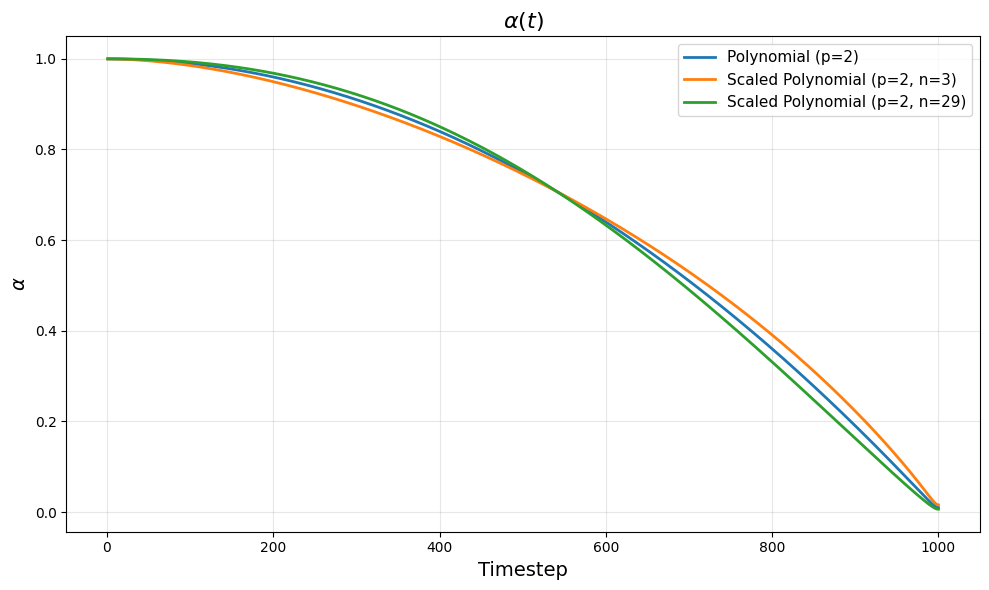

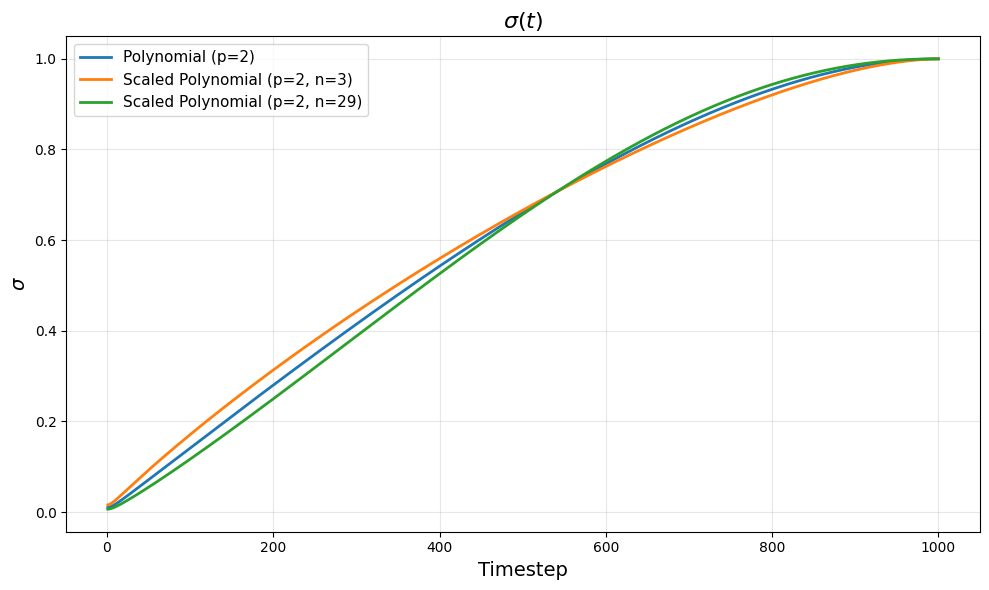

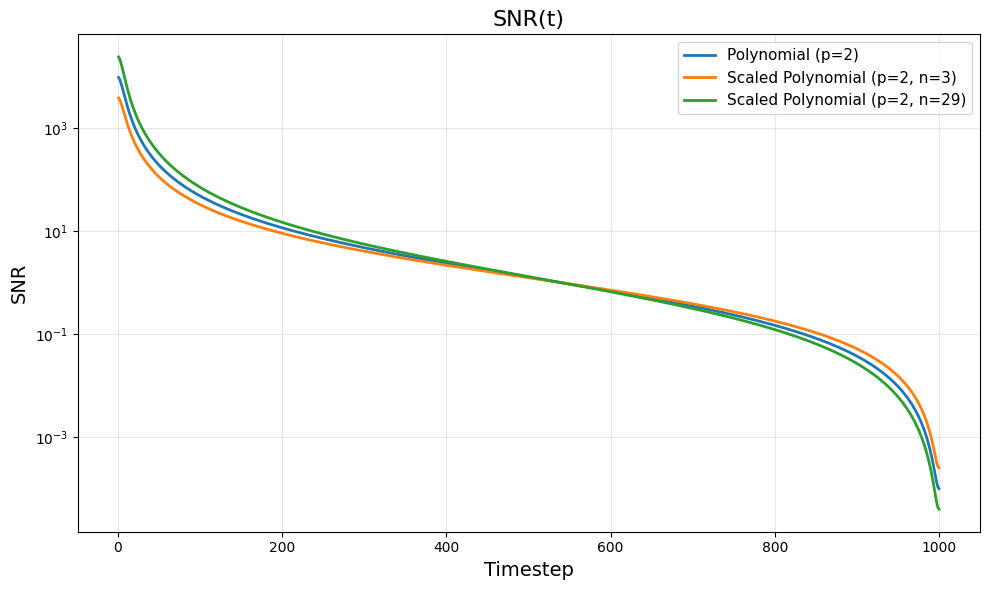

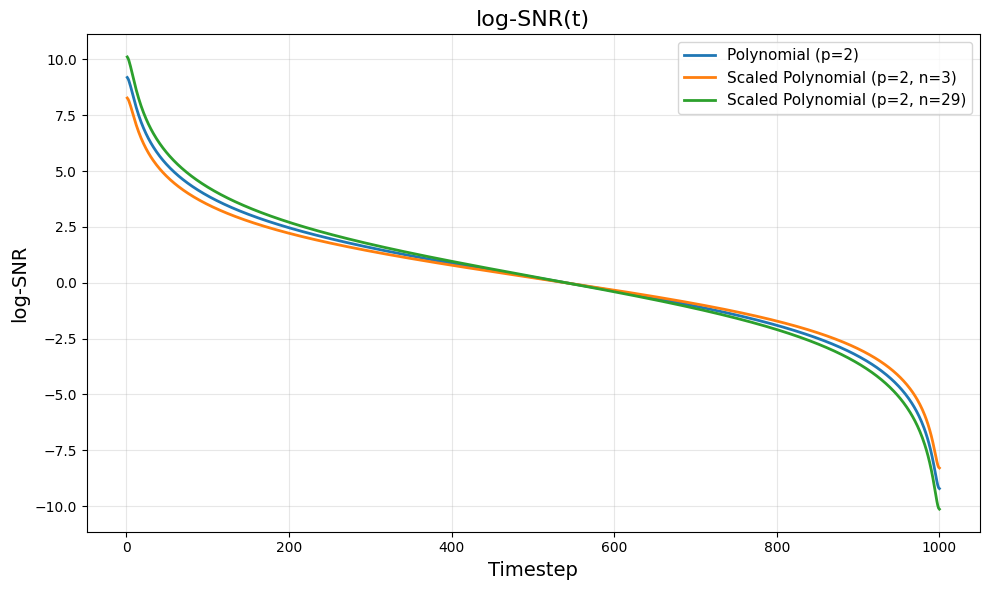

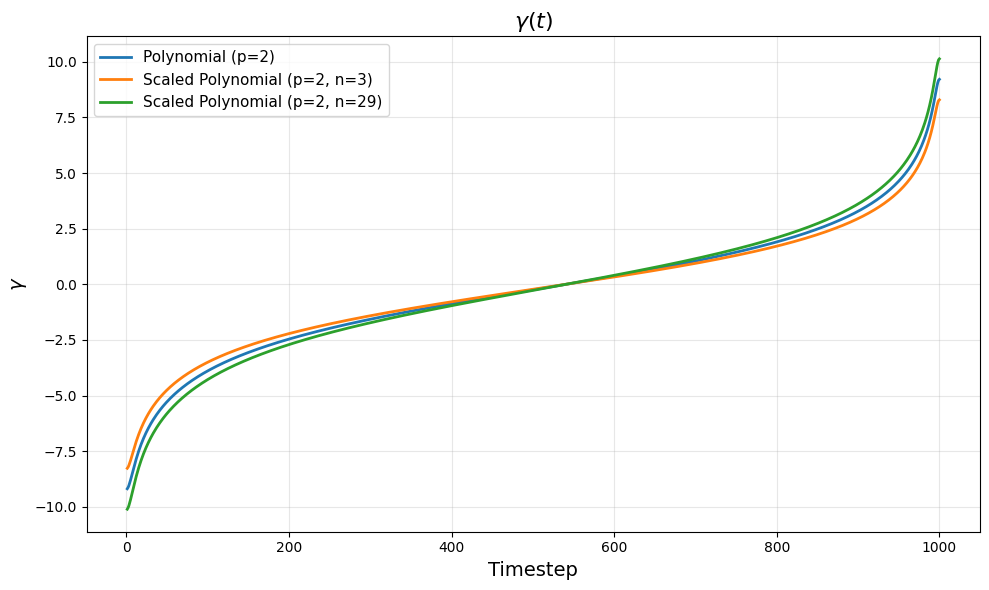

In [18]:
predefined_vs_scaled()

### learned schedules 

Noise Schedule class: LearnedAdaptiveNoiseSchedule
  - dataset_info: None
  - noise_context: None
  - input_dim: 1
  - __class__: <class 'equivariant_diffusion.en_diffusion.LearnedAdaptiveNoiseSchedule'>
Noise Schedule class: LearnedAdaptiveNoiseSchedule
  - dataset_info: None
  - noise_context: None
  - input_dim: 1
  - __class__: <class 'equivariant_diffusion.en_diffusion.LearnedAdaptiveNoiseSchedule'>


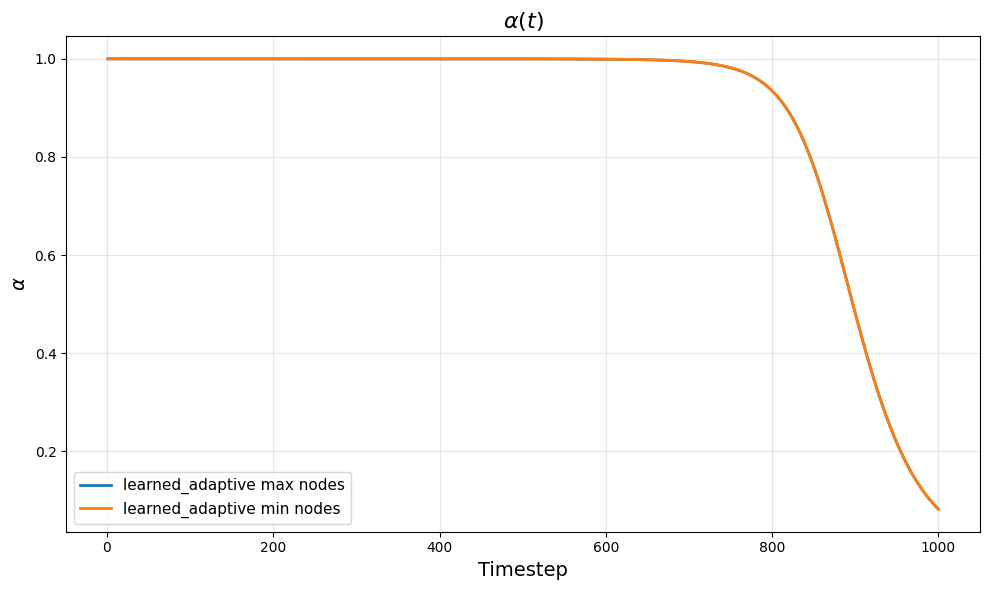

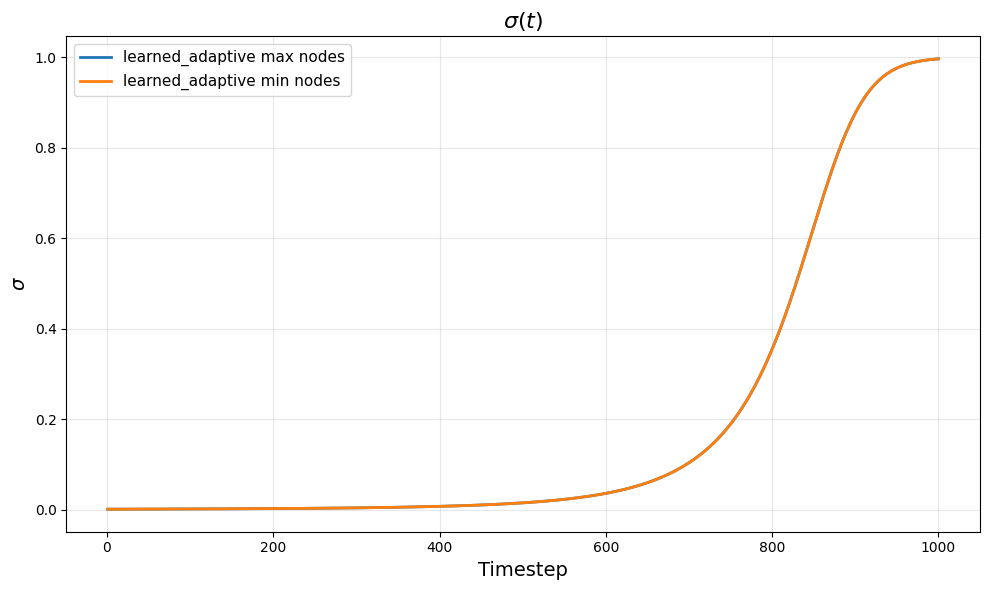

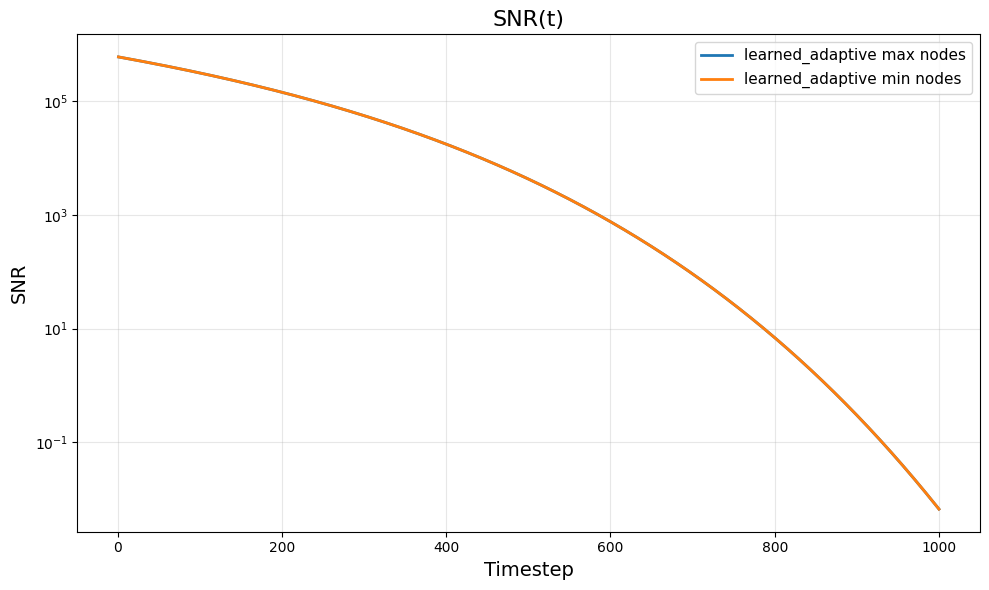

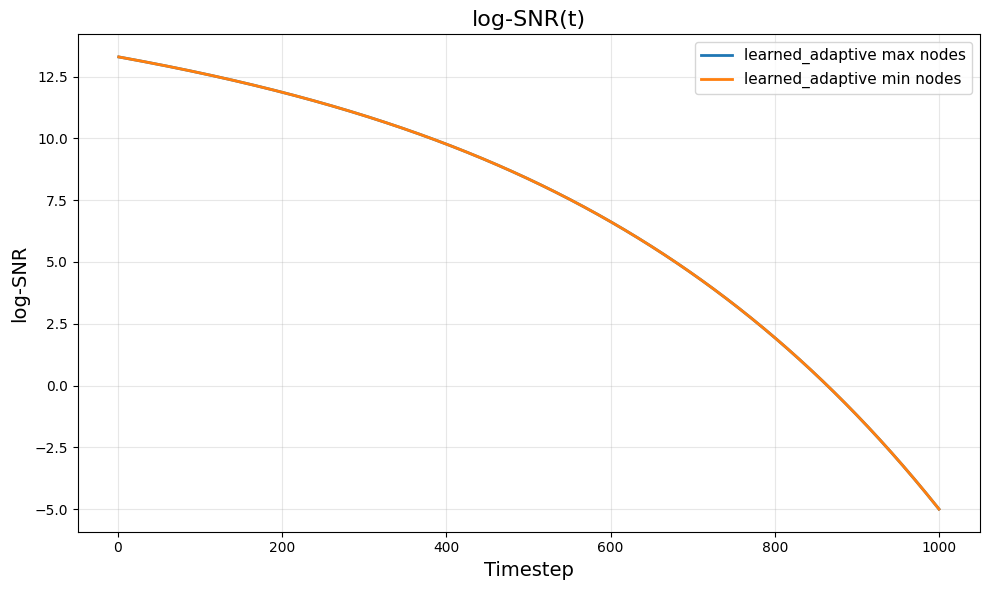

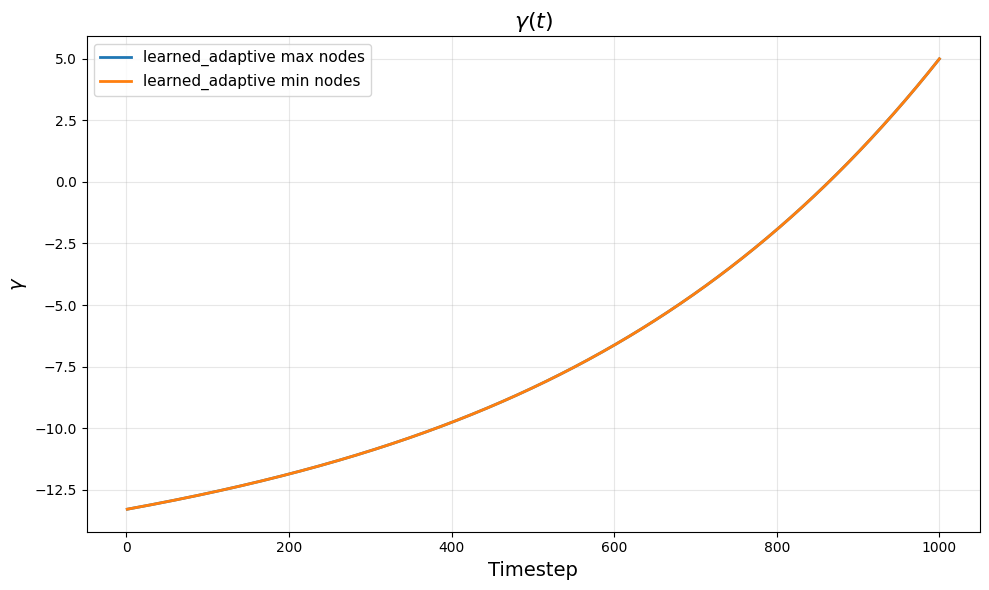

In [19]:
learned()

### predefined vs learned

Noise Schedule class: LearnedAdaptiveNoiseSchedule
  - dataset_info: None
  - noise_context: None
  - input_dim: 1
  - __class__: <class 'equivariant_diffusion.en_diffusion.LearnedAdaptiveNoiseSchedule'>
Noise Schedule class: PredefinedNoiseSchedule
  - noise_schedule: polynomial_2.0
  - timesteps: 1000
  - precision: 0.0001
  - __class__: <class 'equivariant_diffusion.en_diffusion.PredefinedNoiseSchedule'>
alphas2 [9.99900000e-01 9.99898000e-01 9.99892002e-01 ... 1.15964822e-04
 1.03995202e-04 1.00003995e-04]
gamma [-9.21024037 -9.19043967 -9.13328629 ...  9.0621077   9.1710618
  9.21020041]


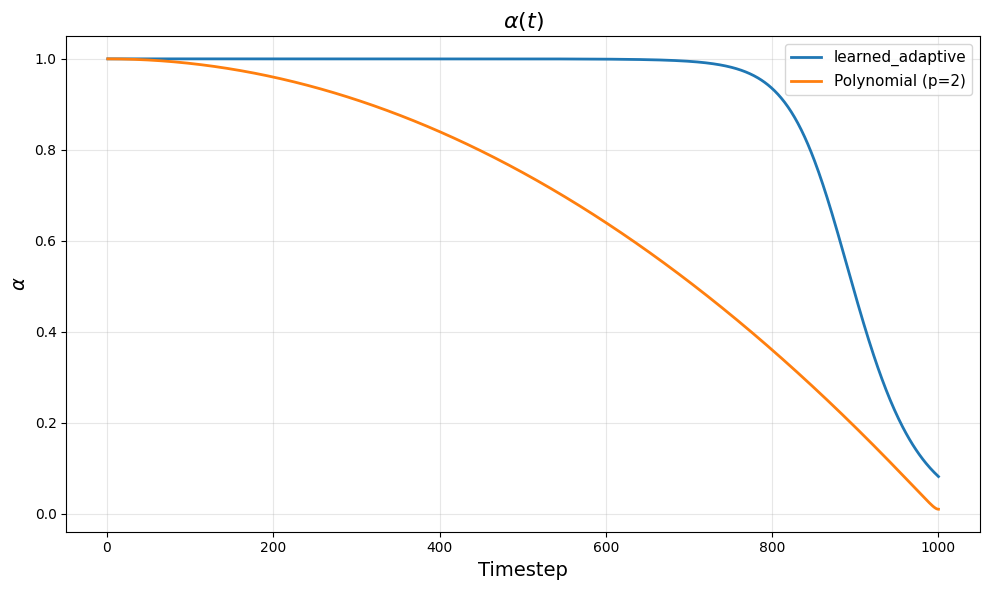

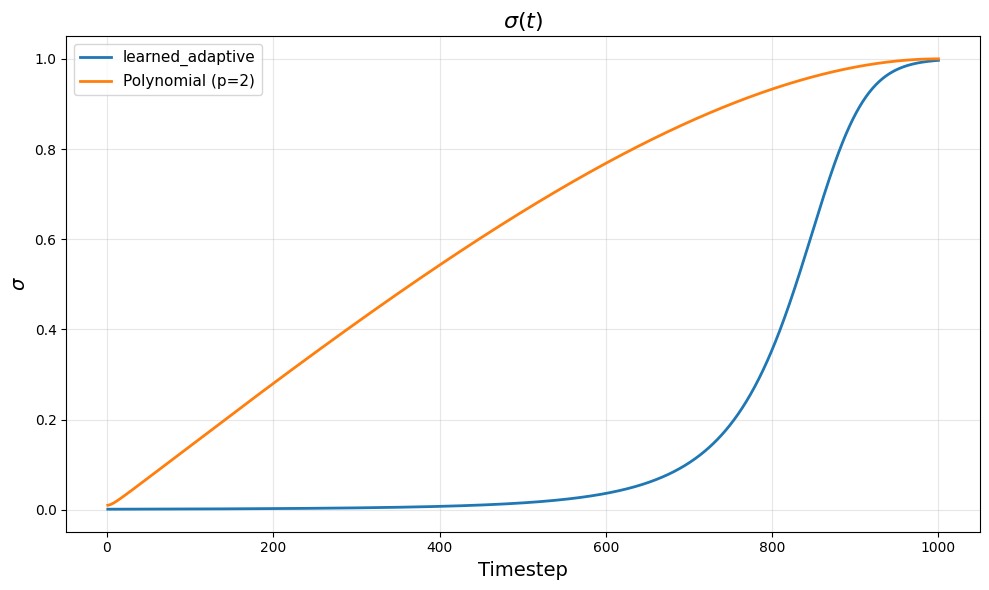

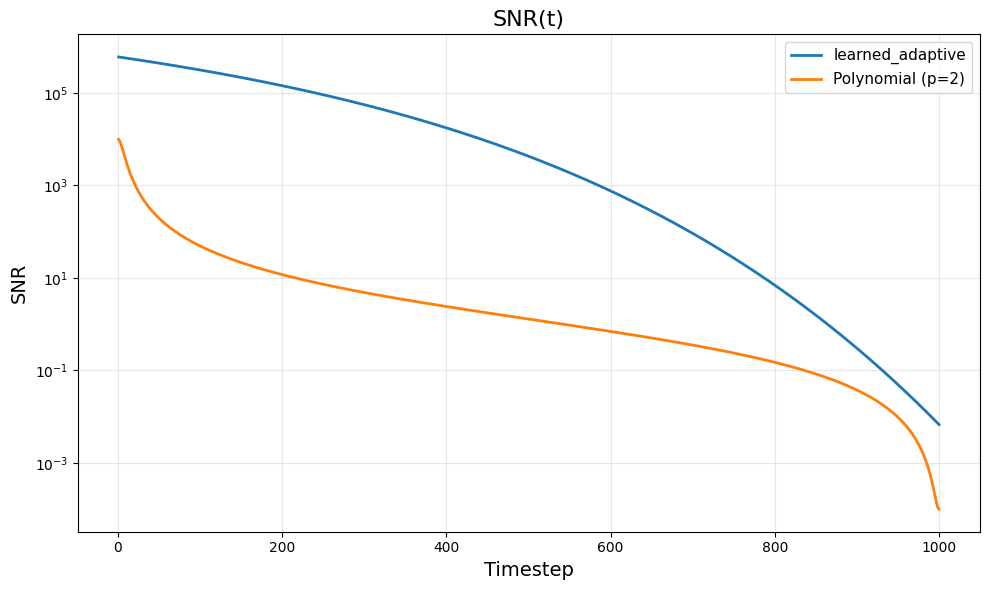

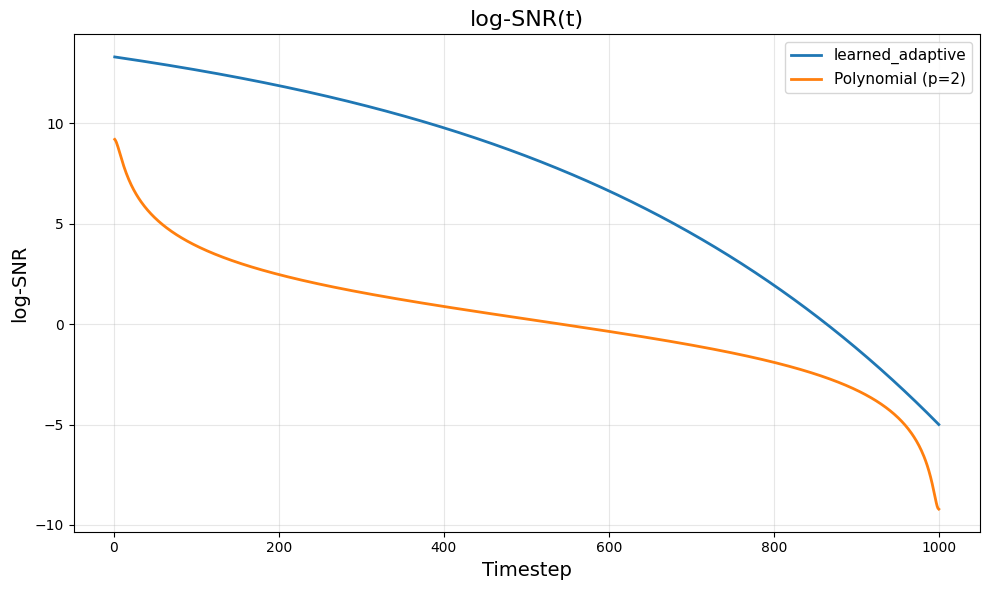

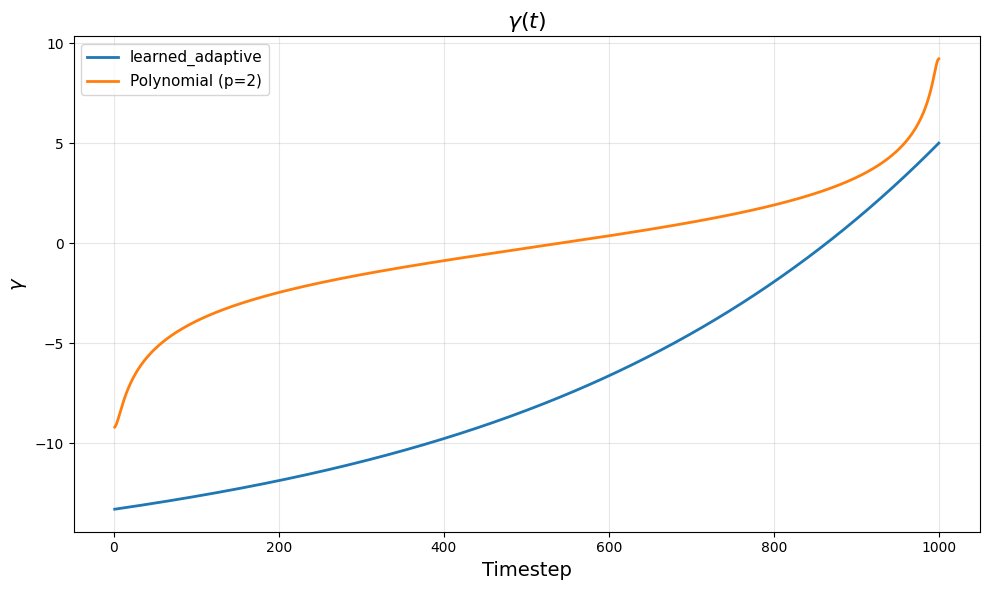

In [20]:
predefined_vs_learned()